In [1]:
## 2026.08.20 CODEX PDAC twin of CODEX_hcc/HCC_train_validate_cv_UNIlabel_all.ipynb
## Cross-dataset training on 278 annotated Pancreas TMA cores (s1167)
## Incomplete_Cases: 195 cores without cell-type CSV → stardist_Incomplete_Cases/
##
## CLI equivalent:
##   conda run --no-capture-output -n SeededNTM python -u \
##     code/CODEX_pdac/PDAC_train_validate_cv_UNIlabel.py --mode cross-dataset \
##     --use-spatial-context --spatial-k 8 --spatial-mode mean \
##     --pooled-save-result result_all_spatial_pdac
##
## Hierarchy (three-head):
##   L2  = final_CT          (fine / celltype_level2)
##   L12 = final_sublineage  (intermediate / celltype_level1)
##   L1  = final_lineage     (coarse / celltype_level0)
##
## Preprocess CSVs first:
##   conda run -n SeededNTM python code/CODEX_pdac/match_codex_cells_with_pixel.py
## Env: conda activate SeededNTM

## 2026.08.28 Train Hist2Pheno on 278 annotated PDAC cores, see prediction results

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("NCRT_CUDA_DEVICE", "0")
import sys as _sys
_pkg_dir = "/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg"
if _pkg_dir not in _sys.path:
    _sys.path.insert(0, _pkg_dir)
from runtime_env import configure_notebook_runtime
_rt_env = configure_notebook_runtime()
NCRT_PHYSICAL_GPU = _rt_env["physical_gpu"]


CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [3]:
import sys
import importlib
import pandas as pd
from pathlib import Path

path = "/home/lingyu/ssd2/Python/"
for _d in (
    f"{path}Hist2Pheno/code/Hist2Pheno_pkg",
    f"{path}Hist2Pheno/code/CODEX_pdac",
):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import base
import plot
import model as model_pkg
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)

import PDAC_train_validate_cv_UNIlabel as pdac_cli
importlib.reload(pdac_cli)

print("Imports OK")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')} (physical GPU {NCRT_PHYSICAL_GPU})")


Loading dependencies...
Loading dependencies...
Imports OK
CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [4]:
## CUDA/CPU sanity check + reproducibility
import torch
import random
import numpy as np

print(sys.executable)
print(f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | cuda.is_available: {torch.cuda.is_available()}")
pdac_cli.setup_cuda(os.environ.get("NCRT_CUDA_DEVICE", "0"))
device = pdac_cli.setup_device(allow_cpu=False)
SEED = 42
pdac_cli.setup_seed(SEED)
print(f"device: {device}")


/nobackup2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
device: cuda:0


## Cross-dataset config

Pool `s1167/{ACQUISITION_ID}/{ACQUISITION_ID}_matched_features.h5ad` for the **278 annotated** PDAC cores.
GIST is excluded. Unannotated PDAC cores (195) are Incomplete_Cases in §6.


In [5]:
from uni_label_cv_helpers import (
    RESULT_FIG,
    make_pooled_result_fig,
    make_pooled_stardist_result_fig,
    stardist_all_label_h5ad_path,
    stardist_incomplete_all_label_h5ad_path,
)

S1167_ROOT = Path(f"{path}Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167")
DATA_ROOT = S1167_ROOT
CASES_ROOT = S1167_ROOT
save_result = "result_all_spatial_pdac"

QUICK_VALIDATE = False
VALIDATION_SUBSET = [
    "Charvill-94_c001_v001_r001_reg001",
    "Charvill-94_c001_v001_r001_reg002",
    "Charvill-94_c003_v001_r001_reg001",
]

all_samples = pdac_cli.discover_pdac_samples(CASES_ROOT, require_h5ad=False, require_cells_csv=True)
_acq_map = pdac_cli.load_he_acq_map(CASES_ROOT)
_target = VALIDATION_SUBSET if QUICK_VALIDATE else all_samples
for _s in _target:
    _h5 = CASES_ROOT / _s / f"{_s}_matched_features.h5ad"
    if _h5.is_file():
        continue
    print(f"Building HE h5ad for {_s} ...", flush=True)
    _ctx = pdac_cli.RunContext(
        sample=_s,
        cases_root=CASES_ROOT,
        python_root=Path(path),
        therapy_data=_s,
        therapy_model=pdac_cli.DEFAULT_THERAPY_MODEL,
        save_result="result",
        device=device,
        seed=SEED,
        match_tolerance=1.0,
        column_rename=dict(pdac_cli.HCC_COLUMN_RENAME),
        force_rebuild_h5ad=False,
        input_dim=None,
        hidden_dims=(1024, 512, 256),
        cv_k=5,
        stratify_target="joint",
        patience=10,
        max_epochs=50,
        train_batch_size=4096,
        resume_from_checkpoints=True,
        ablation_tag="D_emph_L2_spatial",
        hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0,
        build_stardist_h5ad=False,
        acq_id=_acq_map[_s],
        use_spatial_context=True,
        spatial_k=8,
        spatial_mode="mean",
    )
    pdac_cli.step_he_h5ad(_ctx)

POOLED_SAMPLES = pdac_cli.discover_pdac_samples(
    CASES_ROOT, sample=None, require_h5ad=True, require_cells_csv=True,
)
if QUICK_VALIDATE:
    POOLED_SAMPLES = [s for s in VALIDATION_SUBSET if s in POOLED_SAMPLES]
print(f"Cross-dataset: {len(POOLED_SAMPLES)} datasets (PDAC three-head)")

pooled_result_fig, pooled_result_dir = make_pooled_result_fig(DATA_ROOT, save_result)
FIG = RESULT_FIG
print(f"Results → {pooled_result_dir}")

POOLED_CV_K = 2 if QUICK_VALIDATE else 5
POOLED_MAX_EPOCHS = 1 if QUICK_VALIDATE else 50
POOLED_PATIENCE = 1 if QUICK_VALIDATE else 10
POOLED_TRAIN_GROUP_FRAC = 0.7
POOLED_TRAIN_BATCH_SIZE = 256 if QUICK_VALIDATE else 4096
POOLED_USE_SPATIAL = True
POOLED_SPATIAL_K = 8
POOLED_SPATIAL_MODE = "mean"
# demo.sh does not pass --ablation-tag → CLI writes cross_dataset_cv/D_emph_L2
# (even with --use-spatial-context). Keep this in sync so we load that run.
SKIP_POOLED_TRAIN = True
POOLED_ABLATION_TAG = "D_emph_L2_smoke" if QUICK_VALIDATE else "D_emph_L2"
POOLED_HIDDEN_DIMS = (1024, 512, 256)
POOLED_HCE = dict(hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0)
POOLED_VAL_SELECTION = pdac_cli.DEFAULT_VAL_SELECTION_METRIC
POOLED_CV_SELECTION = pdac_cli.DEFAULT_CV_SELECTION_METRIC

pooled_ctx = pdac_cli.PooledRunContext(
    data_root=DATA_ROOT,
    cases_root=CASES_ROOT,
    python_root=Path(path),
    samples=POOLED_SAMPLES,
    device=device,
    seed=SEED,
    save_result=save_result,
    input_dim=None,
    hidden_dims=POOLED_HIDDEN_DIMS,
    cv_k=POOLED_CV_K,
    train_group_frac=POOLED_TRAIN_GROUP_FRAC,
    patience=POOLED_PATIENCE,
    max_epochs=POOLED_MAX_EPOCHS,
    train_batch_size=POOLED_TRAIN_BATCH_SIZE,
    resume_from_checkpoints=not QUICK_VALIDATE,
    ablation_tag=POOLED_ABLATION_TAG,
    val_selection_metric=POOLED_VAL_SELECTION,
    cv_selection_metric=POOLED_CV_SELECTION,
    use_spatial_context=POOLED_USE_SPATIAL,
    spatial_k=POOLED_SPATIAL_K,
    spatial_mode=POOLED_SPATIAL_MODE,
    **POOLED_HCE,
)
print(f"Selection: val={POOLED_VAL_SELECTION}, cv={POOLED_CV_SELECTION}")
print(f"Ablation tag: {POOLED_ABLATION_TAG}, batch_size={POOLED_TRAIN_BATCH_SIZE}")
print(f"SKIP_POOLED_TRAIN: {SKIP_POOLED_TRAIN} (True = load demo.sh checkpoint, no retrain)")
if POOLED_USE_SPATIAL:
    print(f"Spatial context: k={POOLED_SPATIAL_K}, mode={POOLED_SPATIAL_MODE!r}")


Cross-dataset: 278 datasets (PDAC three-head)
Results → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac
Selection: val=three_tier_auc_sum, cv=three_tier_auc_sum
Ablation tag: D_emph_L2, batch_size=4096
SKIP_POOLED_TRAIN: True (True = load demo.sh checkpoint, no retrain)
Spatial context: k=8, mode='mean'


## §1 Load pooled h5ad and prepare CV arrays


In [6]:
pdac_cli.step_pooled_prepare(pooled_ctx)



[Pooled prepare] 278 datasets
  Charvill-94_c001_v001_r001_reg002: 4,745 cells
  Charvill-94_c001_v001_r001_reg003: 4,049 cells
  Charvill-94_c001_v001_r001_reg012: 4,508 cells
  Charvill-94_c001_v001_r001_reg014: 3,568 cells
  Charvill-94_c001_v001_r001_reg026: 3,240 cells
  Charvill-94_c001_v001_r001_reg029: 9,875 cells
  Charvill-94_c001_v001_r001_reg037: 2,122 cells
  Charvill-94_c001_v001_r001_reg047: 1,843 cells
  Charvill-94_c001_v001_r001_reg058: 9,265 cells
  Charvill-94_c001_v001_r001_reg065: 2,779 cells
  Charvill-94_c001_v001_r001_reg071: 6,830 cells
  Charvill-94_c001_v001_r001_reg081: 8,124 cells
  Charvill-94_c001_v001_r001_reg092: 5,304 cells
  Charvill-94_c001_v001_r001_reg102: 6,525 cells
  Charvill-94_c001_v001_r001_reg111: 5,718 cells
  Charvill-94_c001_v001_r001_reg121: 4,997 cells
  Charvill-94_c001_v001_r001_reg132: 4,452 cells
  Charvill-94_c001_v001_r001_reg139: 5,439 cells
  Charvill-94_c003_v001_r001_reg006: 2,774 cells
  Charvill-94_c003_v001_r001_reg017: 7

## §2 Load trained model (or group K-fold training)

`SKIP_POOLED_TRAIN=True` loads `cross_dataset_cv/D_emph_L2/best_mlp_gpu.pt` from the demo.sh run. Set it `False` only if you want to train again.


In [7]:
if SKIP_POOLED_TRAIN:
    try:
        pdac_cli._ensure_pooled_inference_ready(pooled_ctx, require_train_if_missing=False)
        print("Loaded existing checkpoint (no retrain).")
        print("BEST_MLP_CHECKPOINT:", pooled_ctx.g.get("BEST_MLP_CHECKPOINT"))
    except FileNotFoundError as exc:
        print(exc)
        print("No best_mlp_gpu.pt yet. Re-run this cell when training finishes.")
        print("Do not set SKIP_POOLED_TRAIN=False — that would start a second train.")
    print("HE OOF ROC :", pooled_ctx.result_dir / "roc_internal_level2_oof.pdf")
    print("StarDist   :", pooled_ctx.result_dir / "stardist")
else:
    pdac_cli.step_pooled_train(pooled_ctx)
    print("BEST_MLP_CHECKPOINT:", pooled_ctx.g.get("BEST_MLP_CHECKPOINT"))


  Using existing checkpoint: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/cross_dataset_cv/D_emph_L2/best_mlp_gpu.pt
Loaded existing checkpoint (no retrain).
BEST_MLP_CHECKPOINT: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/cross_dataset_cv/D_emph_L2/best_mlp_gpu.pt
HE OOF ROC : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/roc_internal_level2_oof.pdf
StarDist   : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist


## §3 Internal validation (OOF) — L2 / L12 / L1


In [8]:
if SKIP_POOLED_TRAIN:
    print("Skip §3 replot: OOF figures already written by demo.sh.")
    for name in ("roc_internal_level2_oof.pdf", "conf_matrix_level2.pdf", "validation_internal_metrics.csv"):
        print(" ", pooled_ctx.result_dir / name)
else:
    pdac_cli.step_pooled_he_validate(pooled_ctx)


Skip §3 replot: OOF figures already written by demo.sh.
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/roc_internal_level2_oof.pdf
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/conf_matrix_level2.pdf
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/validation_internal_metrics.csv


## §4 StarDist predict (matched, with GT AUROC)

Requires `{acq}_matched_features_stardist.h5ad` from `transer_embedding_label_h5ad.py`.
Outputs under `s1167/{save_result}/stardist/{ACQUISITION_ID}/`.


In [9]:
pdac_cli._ensure_pooled_inference_ready(pooled_ctx, require_train_if_missing=False)
print("Using", pooled_ctx.g.get("BEST_MLP_CHECKPOINT"))
print("Existing StarDist plots are under", pooled_ctx.result_dir / "stardist")
print("Uncomment the next lines only if you want to re-predict (slow; overwrites JPGs/PDFs).")
# pdac_cli.step_pooled_stardist(pooled_ctx, levels=["l2"])
# pdac_cli.step_pooled_stardist(pooled_ctx, levels=["l1"])
# pdac_cli.step_pooled_stardist(pooled_ctx, levels=["l12"])


Using /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/cross_dataset_cv/D_emph_L2/best_mlp_gpu.pt
Existing StarDist plots are under /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist
Uncomment the next lines only if you want to re-predict (slow; overwrites JPGs/PDFs).


## §5 StarDist predict on **all nuclei** of the **278 annotated** cores

Input: `s1167/{acq}/{acq}_all_features_stardist.h5ad`
Output: `s1167/{save_result}/stardist/{acq}/{acq}_all_features_stardist_label.h5ad`


In [10]:
pdac_cli._ensure_pooled_inference_ready(pooled_ctx, require_train_if_missing=False)
if "BEST_MLP_CHECKPOINT" not in pooled_ctx.g:
    raise RuntimeError("Run §2 first (load checkpoint or train).")
print("Uncomment step_pooled_stardist_all only if you want to re-predict all nuclei (slow).")
# pdac_cli.step_pooled_stardist_all(pooled_ctx)
for sample in POOLED_SAMPLES[:5]:
    print(" ", stardist_all_label_h5ad_path(DATA_ROOT, sample, save_result))
if len(POOLED_SAMPLES) > 5:
    print(f"  ... +{len(POOLED_SAMPLES) - 5} more samples")


Uncomment step_pooled_stardist_all only if you want to re-predict all nuclei (slow).
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist/Charvill-94_c001_v001_r001_reg002/Charvill-94_c001_v001_r001_reg002_all_features_stardist_label.h5ad
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist/Charvill-94_c001_v001_r001_reg003/Charvill-94_c001_v001_r001_reg003_all_features_stardist_label.h5ad
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist/Charvill-94_c001_v001_r001_reg012/Charvill-94_c001_v001_r001_reg012_all_features_stardist_label.h5ad
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist/Charvill-94_c001_v001_r001_reg014/Charvill-94_c001_v001_r001_reg014_all_features_stardist_label.h5ad
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Mi

## §6 Incomplete_Cases — 195 PDAC cores without cell-type CSV

Analog of Xenium `Incomplete_Cases` / HCC rest. Same pooled checkpoint from §2.

Input still lives under `s1167/{acq}/` (not a copied folder).
Output: `s1167/{save_result}/stardist_Incomplete_Cases/{acq}/..._label.h5ad`

Build inputs first:

```bash
conda run --no-capture-output -n SeededNTM python -u \
  code/CODEX_pdac/transer_embedding_label_h5ad.py \
  --incomplete --steps stardist_all_h5ad
```


In [11]:
INCOMPLETE_ALL = pdac_cli.discover_pdac_incomplete_samples(
    CASES_ROOT, require_h5ad=False,
)
INCOMPLETE_SAMPLES = pdac_cli.discover_pdac_incomplete_samples(
    CASES_ROOT, require_h5ad=True,
)
print(f"Incomplete_Cases (no cell-type CSV): {len(INCOMPLETE_ALL)}")
print(f"Ready for inference: {len(INCOMPLETE_SAMPLES)}")
pdac_cli._ensure_pooled_inference_ready(pooled_ctx, require_train_if_missing=False)
if "BEST_MLP_CHECKPOINT" not in pooled_ctx.g:
    raise RuntimeError("Run §2 first (load checkpoint or train).")
print("Uncomment step_pooled_stardist_all_incomplete only if you want to re-predict (slow).")

# pdac_cli.step_pooled_stardist_all_incomplete(pooled_ctx, INCOMPLETE_SAMPLES)

print(f"StarDist-all Incomplete_Cases label h5ads → {pooled_result_dir / 'stardist_Incomplete_Cases'}")
for sample in INCOMPLETE_SAMPLES[:5]:
    out = stardist_incomplete_all_label_h5ad_path(DATA_ROOT, sample, save_result)
    if out.is_file():
        print(f"  {sample}: {out.name}")
if len(INCOMPLETE_SAMPLES) > 5:
    print(f"  ... +{len(INCOMPLETE_SAMPLES) - 5} more samples")


Incomplete_Cases (no cell-type CSV): 195
Ready for inference: 195
Uncomment step_pooled_stardist_all_incomplete only if you want to re-predict (slow).

[Pooled StarDist all nuclei — Incomplete_Cases] 195 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/cross_dataset_cv/D_emph_L2/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  Charvill-94_c007_v001_r001_reg001: saved Charvill-94_c007_v001_r001_reg001_all_features_stardist_label.h5ad (8,407 cells; 21 prob columns; heads=['l1', 'l12', 'l2'])
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/cross_dataset_cv/D_emph_L2/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  Charvill-94_c007_v001_r001_reg002: saved Charvill-94_

In [12]:
import anndata as ad

# Inspect the first Incomplete_Cases sample with a written label h5ad.
_inc_demo = next(
    (
        s for s in INCOMPLETE_SAMPLES
        if stardist_incomplete_all_label_h5ad_path(DATA_ROOT, s, save_result).is_file()
    ),
    None,
)
if _inc_demo is None:
    print("No Incomplete_Cases label h5ad yet — run the cell above (and build missing *_all_features_stardist.h5ad).")
else:
    _inc_h5ad = stardist_incomplete_all_label_h5ad_path(DATA_ROOT, _inc_demo, save_result)
    print(f"Demo Incomplete_Cases: {_inc_demo}\n  {_inc_h5ad}")
    _a = ad.read_h5ad(_inc_h5ad, backed="r")
    try:
        prob_cols = [c for c in _a.obs.columns if "_prob_" in c]
        print(f"  n_obs={_a.n_obs:,}  prob columns={len(prob_cols)}")
        print(f"  heads in uns: {list(_a.uns.get('pred_prob_class_names', {}).keys())}")
        print(f"  sample obs cols: {list(_a.obs.columns[:8])} ...")
    finally:
        _a.file.close()


Demo Incomplete_Cases: Charvill-94_c007_v001_r001_reg001
  /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist_Incomplete_Cases/Charvill-94_c007_v001_r001_reg001/Charvill-94_c007_v001_r001_reg001_all_features_stardist_label.h5ad
  n_obs=8,407  prob columns=21
  heads in uns: ['l1', 'l12', 'l2']
  sample obs cols: ['cell_id', 'centroid_x', 'centroid_y', 'probability', 'l2_prob_0', 'l2_prob_1', 'l2_prob_2', 'l2_prob_3'] ...


### Plot cell type


In [13]:
## Predicted spatial maps: Incomplete_Cases × L2 / L12 / L1 (pred-only).
## JPGs: stardist_Incomplete_Cases/{acq}/{acq}_stardist_pred_{l2,l12,l1}.jpg
## Full 195 × 3 JPGs is too many — default to the first 6 cores.
import importlib
import uni_label_cv_helpers as uni_nb
import s1167_plot
importlib.reload(uni_nb)
importlib.reload(s1167_plot)

if "INCOMPLETE_SAMPLES" not in globals() or not INCOMPLETE_SAMPLES:
    INCOMPLETE_SAMPLES = pdac_cli.discover_pdac_incomplete_samples(
        CASES_ROOT, require_h5ad=True,
    )

PLOT_INCOMPLETE_N = 6  # set None to plot every Incomplete_Cases core
INCOMPLETE_PLOT = (
    INCOMPLETE_SAMPLES if PLOT_INCOMPLETE_N is None
    else INCOMPLETE_SAMPLES[:PLOT_INCOMPLETE_N]
)
print(
    f"Plotting Incomplete_Cases × {s1167_plot.PDAC_STARDIST_MACRO_AUROC_TIERS}: "
    f"{len(INCOMPLETE_PLOT)}/{len(INCOMPLETE_SAMPLES)} cores"
)
print("Datasets:")
for i, _s in enumerate(INCOMPLETE_PLOT, start=1):
    print(f"  {i}. {_s}")
incomplete_spatial = s1167_plot.plot_pdac_incomplete_stardist_spatial_maps(
    DATA_ROOT, INCOMPLETE_PLOT, save_result, pan_organ=pdac_cli.PAN_ORGAN,
)
print("Done. Datasets plotted:")
for i, _s in enumerate(incomplete_spatial, start=1):
    print(f"  {i}. {_s}")


Plotting Incomplete_Cases × ('l2', 'l12', 'l1'): 6/195 cores
Datasets:
  1. Charvill-94_c007_v001_r001_reg001
  2. Charvill-94_c007_v001_r001_reg002
  3. Charvill-94_c007_v001_r001_reg017
  4. Charvill-94_c007_v001_r001_reg024
  5. Charvill-94_c007_v001_r001_reg025
  6. Charvill-94_c007_v001_r001_reg026


  c007 reg001: n=8,407
Number of valid data points: 8407
Number of cell types: 11
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist_Incomplete_Cases/Charvill-94_c007_v001_r001_reg001/Charvill-94_c007_v001_r001_reg001_stardist_pred_l2.jpg
  saved Charvill-94_c007_v001_r001_reg001_stardist_pred_l2.jpg
Number of valid data points: 8407
Number of cell types: 6
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist_Incomplete_Cases/Charvill-94_c007_v001_r001_reg001/Charvill-94_c007_v001_r001_reg001_stardist_pred_l12.jpg
  saved Charvill-94_c007_v001_r001_reg001_stardist_pred_l12.jpg
Number of valid data points: 8407
Number of cell types: 4
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist_Incomplete_Cases/Charvill-94_c

Overview of 6 dataset(s):
  1. Charvill-94_c007_v001_r001_reg001
  2. Charvill-94_c007_v001_r001_reg002
  3. Charvill-94_c007_v001_r001_reg017
  4. Charvill-94_c007_v001_r001_reg024
  5. Charvill-94_c007_v001_r001_reg025
  6. Charvill-94_c007_v001_r001_reg026
Overview datasets (n=6):
  1. Charvill-94_c007_v001_r001_reg001  n=8,407
  2. Charvill-94_c007_v001_r001_reg002  n=5,703
  3. Charvill-94_c007_v001_r001_reg017  n=2,614
  4. Charvill-94_c007_v001_r001_reg024  n=2,045
  5. Charvill-94_c007_v001_r001_reg025  n=8,085
  6. Charvill-94_c007_v001_r001_reg026  n=8,460
  figsize=12.0 × 21.3 in
Overview → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist_Incomplete_Cases/incomplete_spatial_pred_overview_l2_l12_l1.jpg


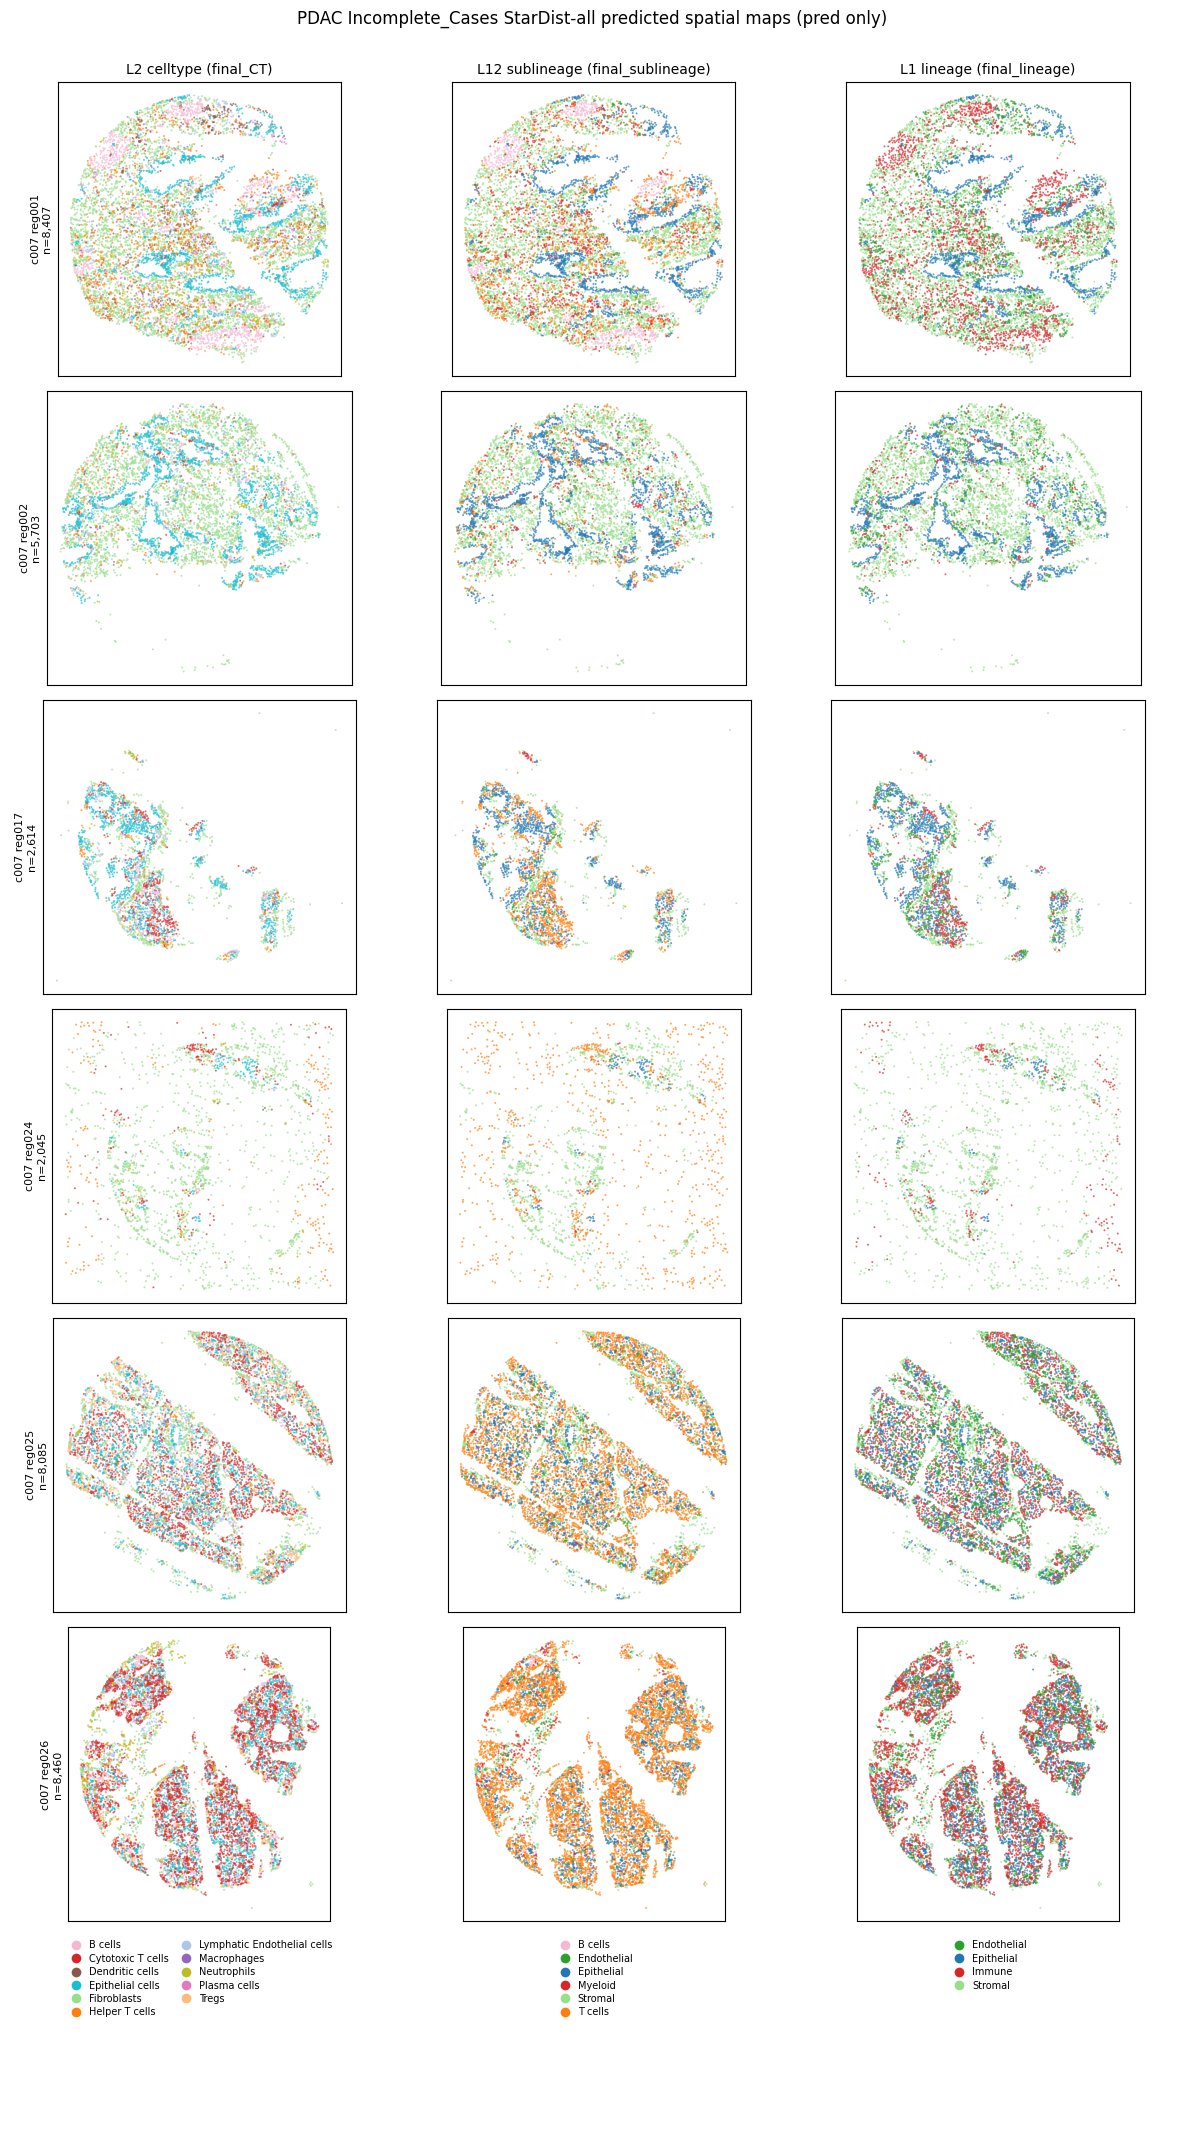

In [14]:
## Overview of the cores plotted above (first 6).
## Bottom row: per-column color legends (L2 / L12 / L1 palettes differ).
import importlib
import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)
print(f"Overview of {len(incomplete_spatial)} dataset(s):")
for i, sample in enumerate(incomplete_spatial, start=1):
    print(f"  {i}. {sample}")
s1167_plot.plot_pdac_incomplete_stardist_spatial_overview(
    incomplete_spatial, DATA_ROOT, save_result,
    pan_organ=pdac_cli.PAN_ORGAN,
    max_per_coverslip=None,
    point_size=2.0,
)


Overview of 1 dataset: Charvill-94_c007_v001_r001_reg002
Overview datasets (n=1):
  1. Charvill-94_c007_v001_r001_reg002  n=5,703
  figsize=12.0 × 5.0 in  dpi=600
Overview → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist_Incomplete_Cases/Charvill-94_c007_v001_r001_reg002_spatial_pred_overview_l2_l12_l1.jpg


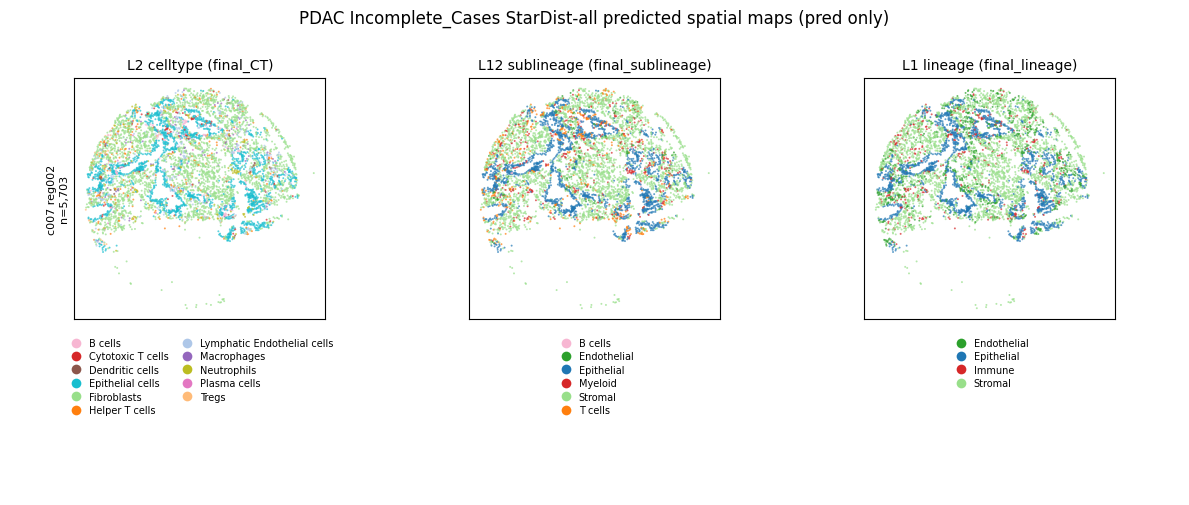

In [ ]:
## Overview the selected one: Charvill-94_c007_v001_r001_reg002
## Bottom row: per-column color legends (L2 / L12 / L1 palettes differ).
import importlib
import uni_label_cv_helpers as uni_nb
import s1167_plot
importlib.reload(uni_nb)
importlib.reload(s1167_plot)

SELECTED_ACQ = "Charvill-94_c007_v001_r001_reg002"
if SELECTED_ACQ in incomplete_spatial:
    selected_spatial = {SELECTED_ACQ: incomplete_spatial[SELECTED_ACQ]}
else:
    print(f"{SELECTED_ACQ} not in incomplete_spatial; loading label h5ad ...")
    selected_spatial = s1167_plot.plot_pdac_incomplete_stardist_spatial_maps(
        DATA_ROOT, [SELECTED_ACQ], save_result, pan_organ=pdac_cli.PAN_ORGAN,
    )
if SELECTED_ACQ not in selected_spatial:
    raise KeyError(f"No loaded record for {SELECTED_ACQ}")
print(f"Overview of 1 dataset: {SELECTED_ACQ}")
s1167_plot.plot_pdac_incomplete_stardist_spatial_overview(
    selected_spatial, DATA_ROOT, save_result,
    pan_organ=pdac_cli.PAN_ORGAN,
    max_per_coverslip=None,
    point_size=2.0,
    figsize=(12, 5),  # (width, height) inches; default ~ (12, 5.3) for 1×3
    save_path=(
        pooled_result_dir / "stardist_Incomplete_Cases"
        / f"{SELECTED_ACQ}_spatial_pred_overview_l2_l12_l1.jpg"
    ),
)


## Notes

- PDAC has **no** CNiche/TNiche (L3/L4); only L2 / L12 / L1.
- §5 writes `stardist/` for the 278 annotated cores; §6 writes `stardist_Incomplete_Cases/` for the 195 cores without cell-type CSV.
- GIST TMA is out of this training track.
- Batch CLI: `PDAC_train_validate_cv_UNIlabel.py --mode cross-dataset`
